# **INTERNSHIP PROJECT REPORT**
## **AI-Powered Customer Delinquency Risk Prediction Using Data Analytics and Machine Learning**

**Submitted by**

## **SHYAMSUNDAR V**

**Register Number:** *253692301025*

**Department:** *MSC DS & AI*

**College:** *DR.MGR Educational and research institute*

**Internship:** *Tata Group – Data Analytics (Forage)*

**Academic Year:** *2025–2027*

# **Phase 1 — Business Understanding**
### **Objective:** Define the business problem, target, stakeholders, and success measure.
### **Why required:** A model is useful only when it solves a real business decision problem.

### **My contribution:** I converted the banking business problem into a supervised machine-learning classification task.

# **Customer Delinquency Prediction**

## **business objective**

Predict whether a customer is likely to become delinquent,
so the bank can take preventive action such as payment reminders,
repayment plans, or early risk intervention.

### **Target:** Delinquent_Account

### **Evaluation metrics:** ['ROC-AUC', 'PR-AUC', 'Recall', 'Precision']


# **Phase 2 — Dataset Understanding**
### **Objective:**  Load the dataset and understand its structure, columns, types, and target.
### **Why required:** Before modelling, it is necessary to understand what the data represents and whether it is usable.
### **My contribution:** I loaded the Excel dataset, identified the target, reviewed data types, and checked the number of records.

In [ ]:
!pip -q install openpyxl joblib

# MODIFICATION: New dataset is CSV (not Excel) and contains 5,000 records.

from google.colab import files
import io
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
TARGET_RAW = "default.payment.next.month"

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(df.describe().T)

print("\nTarget distribution:")
display(df[TARGET_RAW].value_counts().rename_axis(TARGET_RAW).to_frame("Count"))

print("\nDefault percentage:")
display((df[TARGET_RAW].value_counts(normalize=True) * 100).round(2))


Saving UCI_Credit_Card.csv to UCI_Credit_Card (1).csv
Dataset shape: (30000, 25)

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

Data types:


,Data Type
ID,int64
LIMIT_BAL,float64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0



Target distribution:


,Count
default.payment.next.month,
0,23364
1,6636



Default percentage:


,proportion
default.payment.next.month,
0,77.88
1,22.12


# **Phase 3 — Exploratory Data Analysis**
### **Objective:** Identify patterns, imbalance, distributions, and relationships between key variables and delinquency.
### **Why required:** EDA identifies risk patterns and data-quality issues before model development.
### **My contribution:** I analysed class balance, numerical distributions, and delinquency rates across categorical variables.

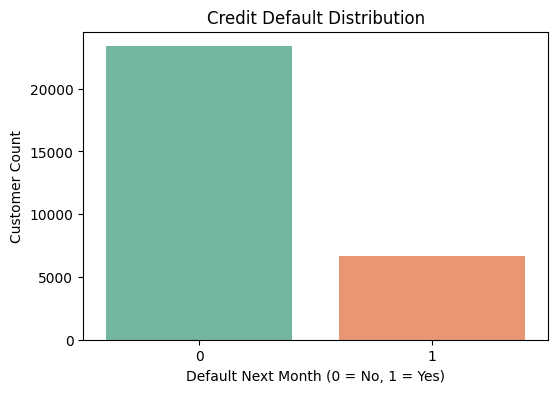

Missing-value report:


,Missing Count,Missing Percentage
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


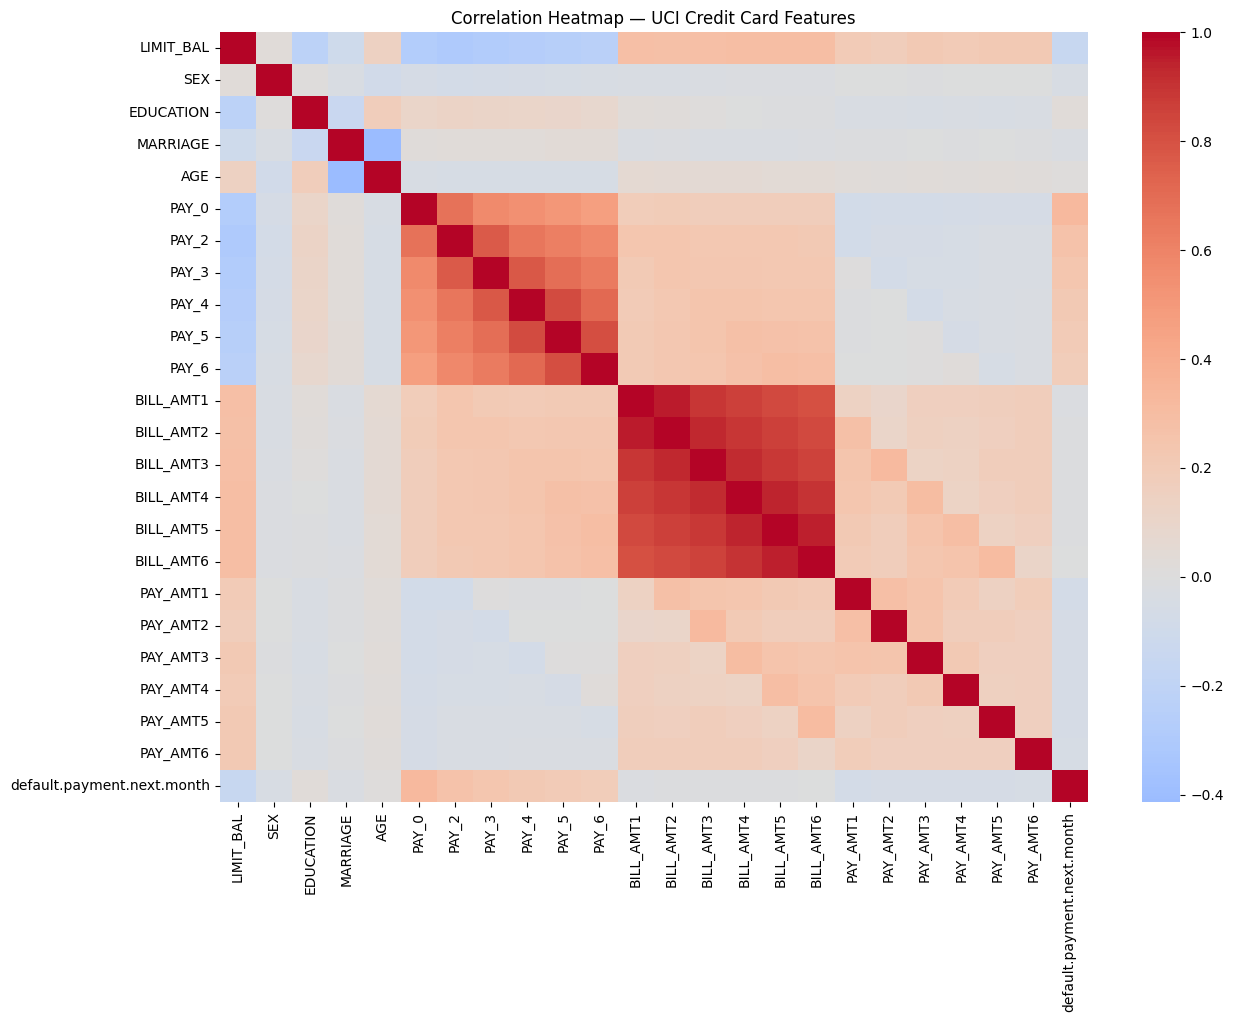

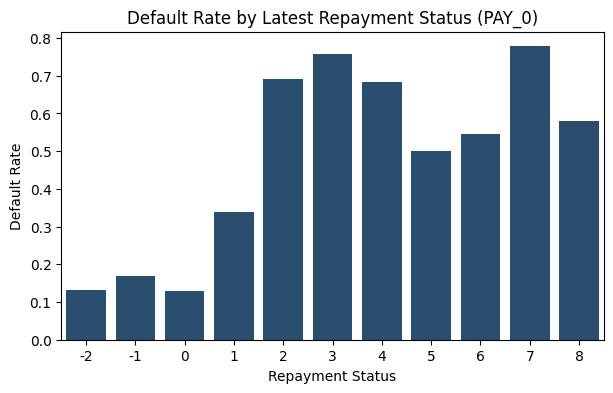

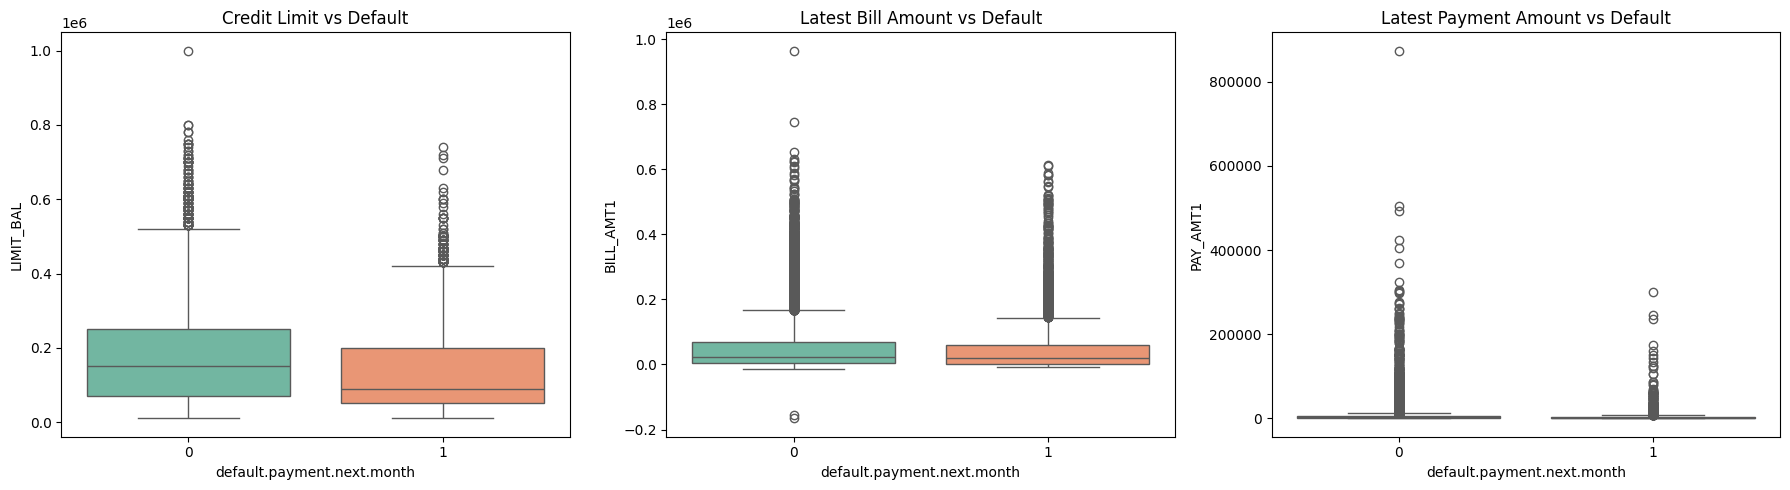

,Potential Outliers
PAY_2,4410
PAY_3,4209
PAY_4,3508
PAY_0,3130
PAY_6,3079
PAY_AMT4,2994
PAY_5,2968
PAY_AMT6,2958
PAY_AMT5,2945
PAY_AMT1,2745


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_RAW, hue=TARGET_RAW, legend=False, palette="Set2")
plt.title("Credit Default Distribution")
plt.xlabel("Default Next Month (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()

# Missing values
missing_values = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

print("Missing-value report:")
display(missing_values)

# Correlation analysis
plt.figure(figsize=(14, 10))
correlation_matrix = df.drop(columns=["ID"]).corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap — UCI Credit Card Features")
plt.show()

# Default rate by selected repayment status
plt.figure(figsize=(7, 4))
sns.barplot(
    data=df,
    x="PAY_0",
    y=TARGET_RAW,
    errorbar=None,
    color="#1f4e79"
)
plt.title("Default Rate by Latest Repayment Status (PAY_0)")
plt.xlabel("Repayment Status")
plt.ylabel("Default Rate")
plt.show()

# Key financial distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x=TARGET_RAW, y="LIMIT_BAL", ax=axes[0], palette="Set2")
axes[0].set_title("Credit Limit vs Default")

sns.boxplot(data=df, x=TARGET_RAW, y="BILL_AMT1", ax=axes[1], palette="Set2")
axes[1].set_title("Latest Bill Amount vs Default")

sns.boxplot(data=df, x=TARGET_RAW, y="PAY_AMT1", ax=axes[2], palette="Set2")
axes[2].set_title("Latest Payment Amount vs Default")

plt.tight_layout()
plt.show()

# IQR outlier report — detection only, not automatic deletion.
# Financial extremes may represent genuine high-value customers.
outlier_report = {}

for col in numeric_cols:
    if col not in ["ID", TARGET_RAW]:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_report[col] = ((df[col] < lower) | (df[col] > upper)).sum()

display(
    pd.DataFrame.from_dict(
        outlier_report,
        orient="index",
        columns=["Potential Outliers"]
    ).sort_values("Potential Outliers", ascending=False)
)

# **Phase 4 — Data Cleaning**
### **Objective:** Remove duplicate records, standardise text values, and validate logical data ranges.
### **Why required:** Inconsistent and duplicate data can produce unreliable model predictions.
### **My contribution:** I removed duplicate records, standardised categorical labels, and checked invalid numerical values.

In [ ]:
clean_df = df.copy()

print("Duplicate records before cleaning:", clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates().copy()
print("Duplicate records after cleaning:", clean_df.duplicated().sum())

# Rename the target to a clean project-friendly name.
clean_df = clean_df.rename(columns={TARGET_RAW: TARGET})

# ID is an identifier, so it is excluded later from modelling.
# Retained temporarily for traceability during analysis.

# UCI category-code cleanup:
# Education values 0, 5 and 6 are grouped as Other/Unknown.
education_mapping = {
    0: "Other",
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other",
    5: "Other",
    6: "Other"
}

marriage_mapping = {
    0: "Other",
    1: "Married",
    2: "Single",
    3: "Other"
}

sex_mapping = {
    1: "Male",
    2: "Female"
}

clean_df["EDUCATION"] = clean_df["EDUCATION"].map(education_mapping)
clean_df["MARRIAGE"] = clean_df["MARRIAGE"].map(marriage_mapping)
clean_df["SEX"] = clean_df["SEX"].map(sex_mapping)

# The original UCI dataset has no missing values.
# Keep this check for professional reproducibility.
print("\nMissing values after cleaning:")
display(clean_df.isna().sum().to_frame("Missing Count"))


Duplicate records before cleaning: 0
Duplicate records after cleaning: 0

Missing values after cleaning:


,Missing Count
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


# **Phase 5 — Feature Engineering**
### **Objective:** Convert raw monthly payment information into meaningful risk indicators.
### **Why required:** Derived features make customer behaviour easier for the model to learn.
### **My contribution:** I converted six monthly repayment columns into payment-risk features.

In [ ]:
feature_df = clean_df.copy()

pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
payment_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

# Repayment behaviour features
feature_df["Average_Repayment_Status"] = feature_df[pay_status_cols].mean(axis=1)
feature_df["Maximum_Repayment_Delay"] = feature_df[pay_status_cols].max(axis=1)
feature_df["Delayed_Month_Count"] = (feature_df[pay_status_cols] > 0).sum(axis=1)

# Billing and payment behaviour features
feature_df["Average_Bill_Amount"] = feature_df[bill_cols].mean(axis=1)
feature_df["Total_Bill_Amount"] = feature_df[bill_cols].sum(axis=1)
feature_df["Total_Payment_Amount"] = feature_df[payment_cols].sum(axis=1)
feature_df["Average_Payment_Amount"] = feature_df[payment_cols].mean(axis=1)

# Financial utilisation and repayment capability features
feature_df["Bill_to_Limit_Ratio"] = (
    feature_df["Average_Bill_Amount"] /
    feature_df["LIMIT_BAL"].replace(0, np.nan)
)

feature_df["Payment_to_Bill_Ratio"] = (
    feature_df["Total_Payment_Amount"] /
    feature_df["Total_Bill_Amount"].clip(lower=1)
)

# Customer age segment improves business interpretation.
feature_df["Age_Group"] = pd.cut(
    feature_df["AGE"],
    bins=[0, 25, 35, 45, 60, np.inf],
    labels=["18-25", "26-35", "36-45", "46-60", "60+"]
)

display(feature_df[
    [
        "Average_Repayment_Status",
        "Maximum_Repayment_Delay",
        "Delayed_Month_Count",
        "Average_Bill_Amount",
        "Bill_to_Limit_Ratio",
        "Payment_to_Bill_Ratio",
        "Age_Group"
    ]
].head())


,Average_Repayment_Status,Maximum_Repayment_Delay,Delayed_Month_Count,Average_Bill_Amount,Bill_to_Limit_Ratio,Payment_to_Bill_Ratio,Age_Group
0,-0.333333,2,2,1284.000000,0.064200,0.089434,18-25
1,0.500000,2,2,2846.166667,0.023718,0.292791,26-35
2,0.000000,0,0,16942.166667,0.188246,0.108388,26-35
3,0.000000,0,0,38555.666667,0.771113,0.036259,36-45
4,-0.333333,0,0,18223.166667,0.364463,0.540054,46-60


# **Phase 6 — Feature Selection**
### **Objective:** Remove non-useful features and define the final input feature set.
### **Why required:** Irrelevant identifiers and duplicated representations can add noise and reduce model reliability.
### **My contribution:** I removed Customer_ID and raw monthly fields after creating meaningful aggregate features.

In [ ]:
model_df = feature_df.drop(columns=["ID"])

X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

# Remove only extremely correlated numerical fields.
# The threshold is deliberately high to retain meaningful sequential payment data.
numeric_features_before_selection = X.select_dtypes(include=np.number).columns.tolist()

corr_matrix = X[numeric_features_before_selection].corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_correlation_features = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.97)
]

X = X.drop(columns=high_correlation_features)

print("Highly correlated features removed:")
print(high_correlation_features)

print("\nFinal feature count:", X.shape[1])
print("\nFinal selected features:")
print(X.columns.tolist())


Highly correlated features removed:
['Total_Bill_Amount', 'Average_Payment_Amount']

Final feature count: 31

Final selected features:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Average_Repayment_Status', 'Maximum_Repayment_Delay', 'Delayed_Month_Count', 'Average_Bill_Amount', 'Total_Payment_Amount', 'Bill_to_Limit_Ratio', 'Payment_to_Bill_Ratio', 'Age_Group']





# **Phase 7 — Train-Test Split**
### **Objective:** Separate data for model development and unbiased final testing.
### **Why required:** Testing a model on data it has already seen gives misleadingly high performance.
### **My contribution:** I created stratified training and test datasets, preserving the delinquency proportion.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining default rate:", round(y_train.mean() * 100, 2), "%")
print("Testing default rate:", round(y_test.mean() * 100, 2), "%")


Training shape: (24000, 31)
Testing shape: (6000, 31)

Training default rate: 22.12 %
Testing default rate: 22.12 %


# **Phase 8 — Feature Scaling**
### **Objective:** Scale numerical variables when required by the algorithm.
### **Why required:** Logistic Regression is sensitive to different numerical scales; Random Forest is not. Scaling is performed within a pipeline to prevent leakage.
### **My contribution:** I applied median imputation and standard scaling only to numeric fields, while categorical fields were one-hot encoded.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Logistic Regression benefits from scaling numerical data.
logistic_preprocessor = ColumnTransformer(transformers=[
    (
        "numeric",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features
    ),
    (
        "categorical",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", one_hot_encoder)
        ]),
        categorical_features
    )
])

# Tree models do not require scaling.
tree_preprocessor = ColumnTransformer(transformers=[
    (
        "numeric",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        numeric_features
    ),
    (
        "categorical",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", one_hot_encoder)
        ]),
        categorical_features
    )
])

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Average_Repayment_Status', 'Maximum_Repayment_Delay', 'Delayed_Month_Count', 'Average_Bill_Amount', 'Total_Payment_Amount', 'Bill_to_Limit_Ratio', 'Payment_to_Bill_Ratio']
Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE', 'Age_Group']


# **Phase 9 — Model Selection**
### **Objective:** Compare appropriate baseline and non-linear classification models.
### **Why required:** Different algorithms capture different relationships in customer risk data.
### **My contribution:** I selected Logistic Regression for interpretability and Random Forest for non-linear risk patterns.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    "Logistic Regression": {
        "preprocessor": logistic_preprocessor,
        "model": LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    },

    "Decision Tree": {
        "preprocessor": tree_preprocessor,
        "model": DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        )
    },

    "Random Forest": {
        "preprocessor": tree_preprocessor,
        "model": RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    }
}

# XGBoost is included only when available in the Colab environment.
try:
    from xgboost import XGBClassifier

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    models["XGBoost"] = {
        "preprocessor": tree_preprocessor,
        "model": XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    }

    print("XGBoost is available and included in model selection.")
except ImportError:
    print("XGBoost is unavailable. Continuing with three standard models.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

selection_results = []

for model_name, components in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", components["preprocessor"]),
        ("model", components["model"])
    ])

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "ROC-AUC": "roc_auc",
            "PR-AUC": "average_precision",
            "F1": "f1"
        },
        n_jobs=-1
    )

    selection_results.append({
        "Model": model_name,
        "CV ROC-AUC": cv_scores["test_ROC-AUC"].mean(),
        "CV PR-AUC": cv_scores["test_PR-AUC"].mean(),
        "CV F1 Score": cv_scores["test_F1"].mean()
    })

selection_table = (
    pd.DataFrame(selection_results)
    .sort_values("CV ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(selection_table.round(4))

selected_model_name = selection_table.loc[0, "Model"]

print(
    f"Selected model: {selected_model_name}\n"
    f"Selection basis: highest mean cross-validation ROC-AUC."
)


XGBoost is available and included in model selection.


,Model,CV ROC-AUC,CV PR-AUC,CV F1 Score
0,Random Forest,0.7853,0.5588,0.5435
1,XGBoost,0.7814,0.5588,0.5361
2,Logistic Regression,0.7608,0.5085,0.5263
3,Decision Tree,0.7582,0.5261,0.5133


Selected model: Random Forest
Selection basis: highest mean cross-validation ROC-AUC.


# **Phase 10 — Model Training**
### **Objective:** Train and tune models using stratified cross-validation.
### **Why required:** Tuning improves performance while cross-validation reduces dependence on one random split.
### **My contribution:** I tuned both models using GridSearchCV and selected the highest ROC-AUC model.

In [ ]:
trained_models = {}

for model_name, components in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", components["preprocessor"]),
        ("model", components["model"])
    ])

    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    print(f"{model_name} trained successfully.")

best_model = trained_models[selected_model_name]



Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.


# **Phase 11 — Prediction**
### **Objective:** Generate delinquency probabilities and risk labels for unseen customers.
### **Why required:** Business teams need a risk score, not only a technical model.
### **My contribution:** I converted predicted probabilities into actionable delinquency-risk categories.

In [ ]:
all_predictions = {}

for model_name, model_pipeline in trained_models.items():
    probability = model_pipeline.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.50).astype(int)

    all_predictions[model_name] = {
        "probability": probability,
        "prediction": prediction
    }

best_probability = all_predictions[selected_model_name]["probability"]
best_prediction = all_predictions[selected_model_name]["prediction"]

prediction_output = X_test.copy()
prediction_output["Actual_Default"] = y_test.values
prediction_output["Predicted_Default"] = best_prediction
prediction_output["Default_Probability"] = best_probability

prediction_output["Risk_Band"] = pd.cut(
    prediction_output["Default_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

display(
    prediction_output
    .sort_values("Default_Probability", ascending=False)
    .head(10)
)



,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,Delayed_Month_Count,Average_Bill_Amount,Total_Payment_Amount,Bill_to_Limit_Ratio,Payment_to_Bill_Ratio,Age_Group,Actual_Default,Predicted_Default,Default_Probability,Risk_Band
27536,250000.0,Male,Graduate School,Married,51,3,2,2,2,2,...,6,2487.0,0.0,0.009948,0.0,46-60,1,1,0.984681,High Risk
28054,20000.0,Female,University,Married,32,3,2,2,7,7,...,6,2400.0,0.0,0.120000,0.0,26-35,1,1,0.982287,High Risk
28747,50000.0,Female,University,Married,28,3,2,2,7,7,...,6,2400.0,0.0,0.048000,0.0,26-35,0,1,0.979511,High Risk
20721,20000.0,Male,University,Single,37,3,2,2,7,7,...,6,2400.0,0.0,0.120000,0.0,36-45,1,1,0.979064,High Risk
1956,220000.0,Female,Graduate School,Married,42,2,2,2,2,2,...,6,2500.0,0.0,0.011364,0.0,36-45,1,1,0.978283,High Risk
29770,20000.0,Male,Graduate School,Single,31,3,2,2,7,7,...,6,2400.0,0.0,0.120000,0.0,26-35,1,1,0.974633,High Risk
13966,40000.0,Female,High School,Married,55,2,2,7,7,7,...,6,2400.0,0.0,0.060000,0.0,46-60,1,1,0.972427,High Risk
16788,30000.0,Male,University,Single,37,3,2,2,7,7,...,6,2379.0,0.0,0.079300,0.0,36-45,1,1,0.972119,High Risk
14973,30000.0,Male,High School,Married,55,2,2,7,7,7,...,6,2395.0,0.0,0.079833,0.0,46-60,1,1,0.971944,High Risk
673,30000.0,Male,University,Single,25,2,2,7,7,7,...,6,2300.0,0.0,0.076667,0.0,18-25,1,1,0.971352,High Risk


# **Phase 12 — Model Evaluation**
### **Objective:** Measure classification performance on unseen test data.
### **Why required:** A model must be evaluated using multiple metrics, especially with class imbalance.
### **My contribution:** I evaluated ROC-AUC, PR-AUC, precision, recall, F1-score, confusion matrix, ROC curve, and precision-recall curve.

Model Comparison Table


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.7592,0.4667,0.6232,0.5337,0.7766,0.5544
1,Random Forest,0.7818,0.5059,0.5787,0.5399,0.7764,0.5550
2,Decision Tree,0.7332,0.4305,0.6390,0.5144,0.7550,0.5164
3,Logistic Regression,0.7440,0.4420,0.6006,0.5093,0.7475,0.4982



Selected Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0      0.875     0.840     0.857      4673
           1      0.506     0.579     0.540      1327

    accuracy                          0.782      6000
   macro avg      0.691     0.709     0.698      6000
weighted avg      0.794     0.782     0.787      6000



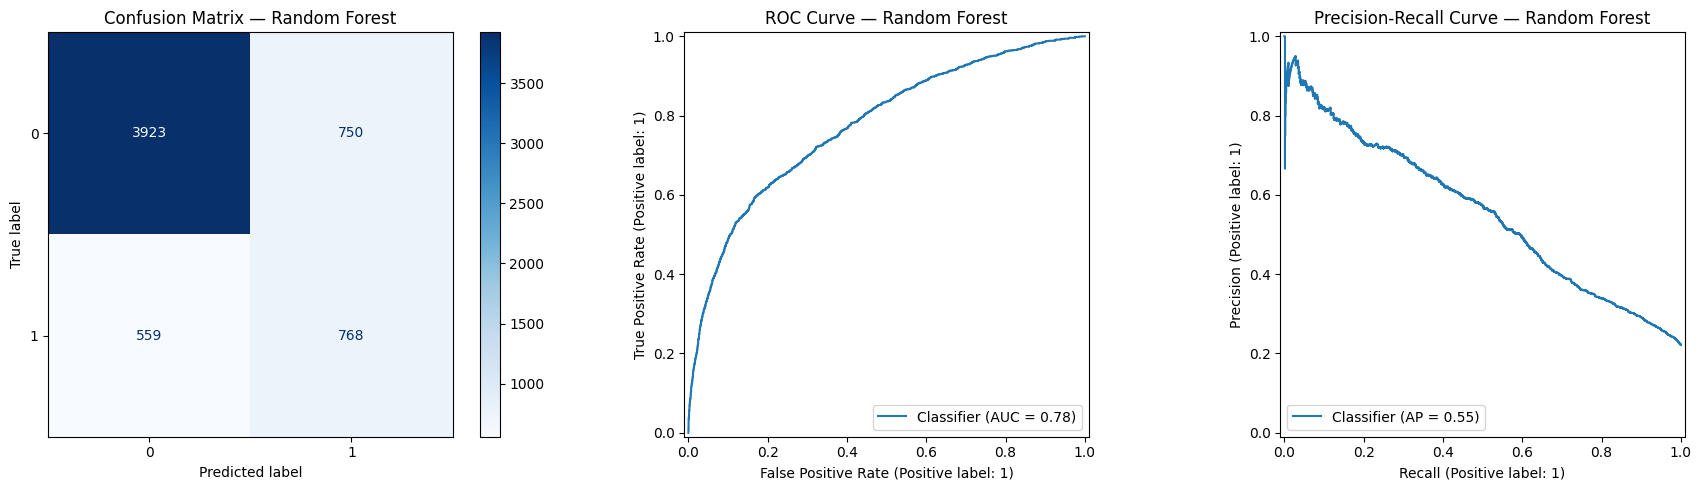

Why Random Forest is the best model:
It achieved the strongest validation ROC-AUC during model selection. ROC-AUC evaluates ranking quality across thresholds, while PR-AUC, recall and F1-score help validate performance for the minority default class.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

evaluation_results = []

for model_name, result in all_predictions.items():
    y_pred = result["prediction"]
    y_prob = result["probability"]

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

evaluation_table = (
    pd.DataFrame(evaluation_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

print("Model Comparison Table")
display(evaluation_table.round(4))

print(f"\nSelected Model: {selected_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, best_prediction, digits=3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_prediction,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix — {selected_model_name}")

RocCurveDisplay.from_predictions(
    y_test,
    best_probability,
    ax=axes[1]
)
axes[1].set_title(f"ROC Curve — {selected_model_name}")

PrecisionRecallDisplay.from_predictions(
    y_test,
    best_probability,
    ax=axes[2]
)
axes[2].set_title(f"Precision-Recall Curve — {selected_model_name}")

plt.tight_layout()
plt.show()

print(
    f"Why {selected_model_name} is the best model:\n"
    f"It achieved the strongest validation ROC-AUC during model selection. "
    f"ROC-AUC evaluates ranking quality across thresholds, while PR-AUC, recall "
    f"and F1-score help validate performance for the minority default class."
)

# **Phase 13 — Business Recommendation**
### **Objective:** Translate predictions into realistic business actions.
### **Why required:** Data science creates value only when model output informs decisions.
My contribution: I proposed a risk-based intervention strategy.

In [ ]:
risk_summary = (
    prediction_output
    .groupby("Risk_Band", observed=False)
    .agg(
        Customer_Count=("Default_Probability", "count"),
        Average_Risk=("Default_Probability", "mean"),
        Actual_Default_Rate=("Actual_Default", "mean")
    )
)

risk_summary["Average_Risk"] = (risk_summary["Average_Risk"] * 100).round(2)
risk_summary["Actual_Default_Rate"] = (
    risk_summary["Actual_Default_Rate"] * 100
).round(2)

display(risk_summary)

business_recommendations = pd.DataFrame({
    "Risk Segment": ["High Risk", "Medium Risk", "Low Risk"],
    "Recommended Business Action": [
        "Prioritise proactive calls, repayment-plan discussion and relationship-manager review.",
        "Use personalised payment reminders, digital nudges and temporary credit monitoring.",
        "Continue normal servicing and monitor for changes in repayment behaviour."
    ],
    "Expected Benefit": [
        "Reduces potential default escalation and improves collection focus.",
        "Encourages early repayment before customer stress becomes severe.",
        "Controls operational cost while maintaining portfolio oversight."
    ]
})

display(business_recommendations)


,Customer_Count,Average_Risk,Actual_Default_Rate
Risk_Band,,,
Low Risk,2725,20.35,8.84
Medium Risk,2114,40.66,19.96
High Risk,1161,76.97,57.19


,Risk Segment,Recommended Business Action,Expected Benefit
0,High Risk,"Prioritise proactive calls, repayment-plan dis...",Reduces potential default escalation and impro...
1,Medium Risk,"Use personalised payment reminders, digital nu...",Encourages early repayment before customer str...
2,Low Risk,Continue normal servicing and monitor for chan...,Controls operational cost while maintaining po...
